In [3]:
!pip3 install imblearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import joblib
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    confusion_matrix,f1_score,accuracy_score,precision_score,recall_score,roc_auc_score,roc_curve,ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IbmPipeline

In [5]:
df = pd.read_csv("titanic.csv")
df.head(3)
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
# droping the rows under < 5% of missing values
df = df.dropna(subset=["embarked", "embark_town"])
print(f"Dropped the rows with missing 'embarked', 'embark_town' rows")

#Imputing the values in the columns where the missing percentage is 5 - 30 % 
df["age"] = df["age"].fillna(df["age"].median())
print(f"Imputed the missing values in the age column with median = {df["age"].median()}")

df = df.drop(columns= ["deck"])

print()
print("Remaining missing values per column after cleaning:")
print(df.isna().sum())


Dropped the rows with missing 'embarked', 'embark_town' rows
Imputed the missing values in the age column with median = 28.0

Remaining missing values per column after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


# **FEATURES AND TARGET SELECTION FOR MODELING**

In [10]:
FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare","embarked"]
TARGET = "survived"

X = df[FEATURES]
y = df[TARGET]


NUMERIC_FEATURES = ["age", "fare", "sibsp", "parch", "pclass"]
CATEGORIAL_FEATURES = ["sex", "embarked"]


print(X.dtypes)
print("\nTarget balance :")
print(y.value_counts(normalize=True).round(3))

pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object

Target balance :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


# **STRATIFIED TRAIN/TEST SPLIT**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state= 42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train survival rate:", y_train.mean().round(3), " Test survival rate:", y_test.mean().round(3))

Train shape: (711, 7)  Test shape: (178, 7)
Train survival rate: 0.383  Test survival rate: 0.382


# **PREPROCESSING [FIT ON TRAINING DATA ONLY]**

In [14]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORIAL_FEATURES),
])

# Quick structural check: fit on train only, transform-only on test
preprocessor.fit(X_train)
feature_names_out = preprocessor.get_feature_names_out()
print("Engineered feature names:", list(feature_names_out))
print("Transformed train shape:", preprocessor.transform(X_train).shape)
print("Transformed test shape:", preprocessor.transform(X_test).shape)

Engineered feature names: ['num__age', 'num__fare', 'num__sibsp', 'num__parch', 'num__pclass', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']
Transformed train shape: (711, 10)
Transformed test shape: (178, 10)


# **TRAIN THREE CLASSIFIERS**

In [16]:
log_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state= 42)),
])

dtree_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=4, random_state=42)),
])

rforest_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42)),
])

models = {
    "Logistic Regression": log_reg_pipe,
    "Decision Tree": dtree_pipe,
    "Random Forest": rforest_pipe,
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


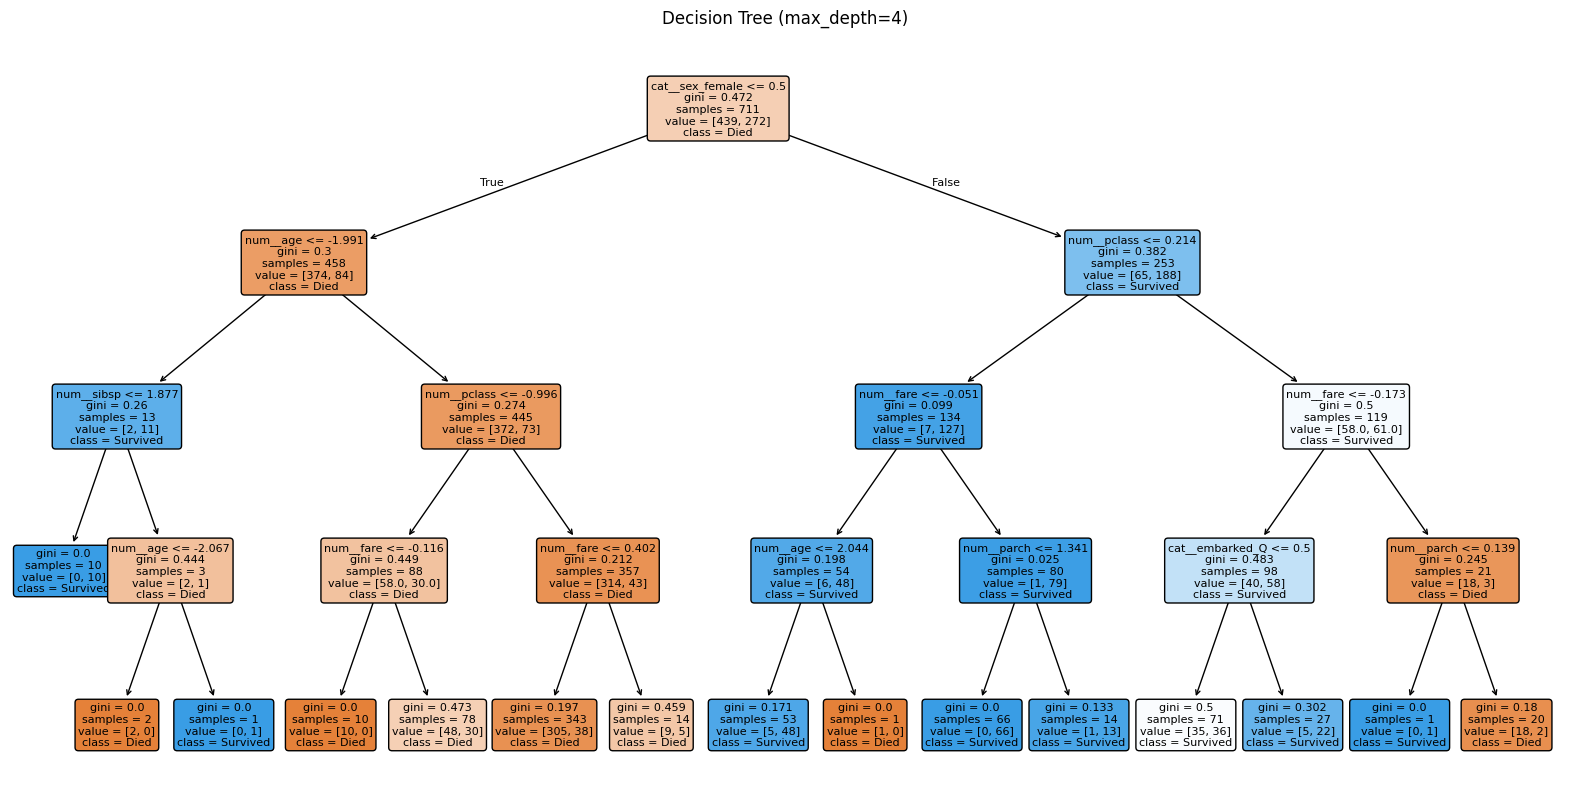

In [17]:
plt.figure(figsize=(20, 10))
plot_tree(
    dtree_pipe.named_steps["classifier"],
    feature_names=list(feature_names_out),
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

# **EVALUATE ALL THREE MODEL**

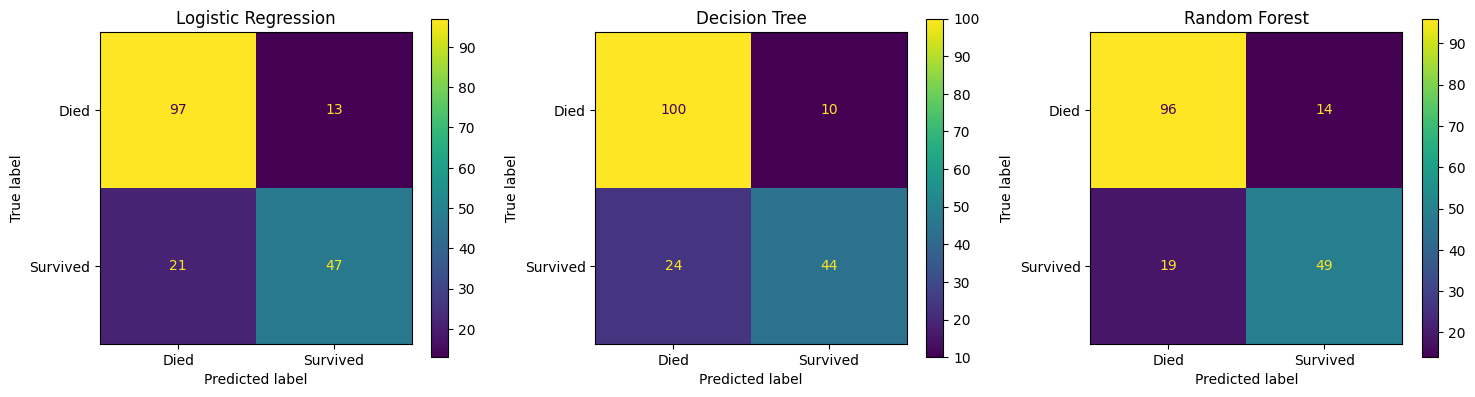

In [19]:
def evaluate_model(name, pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    }

results = {name: evaluate_model(name, pipe, X_test, y_test) for name, pipe in models.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"]).plot(ax=ax, colorbar=True)
    ax.set_title(name)
plt.tight_layout()
plt.show()


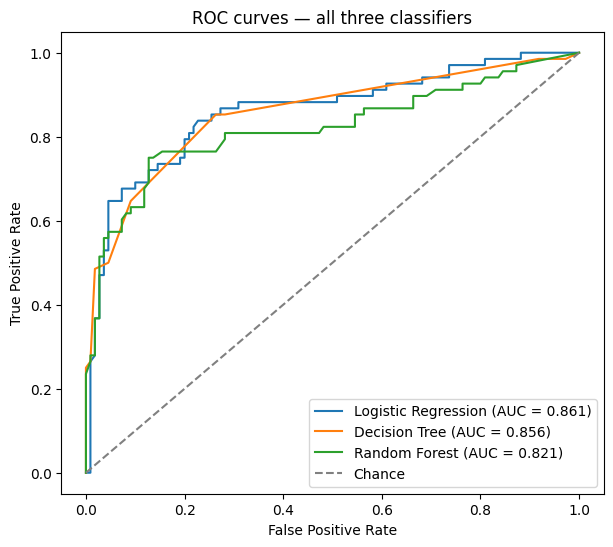

Model comparison table:


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.8090,0.8148,0.6471,0.7213,0.8560
Random Forest,0.8146,0.7778,0.7206,0.7481,0.8215


In [20]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all three classifiers")
plt.legend()
plt.show()

comparison_table = pd.DataFrame([
    {"Model": r["model"], "Accuracy": r["accuracy"], "Precision": r["precision"],
     "Recall": r["recall"], "F1": r["f1"], "AUC": r["auc"]}
    for r in results.values()
]).set_index("Model").round(4)

print("Model comparison table:")
comparison_table


# **IMBALANCE HANDLING COMPARISION**

In [24]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [25]:
# 1. Baseline: reuse Task 9/10 Random Forest results
baseline_res = results["Random Forest"]

# 2. class_weight='balanced'
rf_balanced_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)),
])
rf_balanced_pipe.fit(X_train, y_train)
balanced_res = evaluate_model("RF + class_weight='balanced'", rf_balanced_pipe, X_test, y_test)

# 3. SMOTE applied only to the training fold, via an imblearn Pipeline
rf_smote_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42)),
])
rf_smote_pipe.fit(X_train, y_train)
smote_res = evaluate_model("RF + SMOTE (train fold only)", rf_smote_pipe, X_test, y_test)

imbalance_table = pd.DataFrame([
    {"Strategy": "(a) Baseline (no handling)", "Precision": baseline_res["precision"],
     "Recall": baseline_res["recall"], "F1": baseline_res["f1"]},
    {"Strategy": "(b) class_weight='balanced'", "Precision": balanced_res["precision"],
     "Recall": balanced_res["recall"], "F1": balanced_res["f1"]},
    {"Strategy": "(c) SMOTE (train fold only)", "Precision": smote_res["precision"],
     "Recall": smote_res["recall"], "F1": smote_res["f1"]},
]).set_index("Strategy").round(4)

imbalance_table


,Precision,Recall,F1
Strategy,,,
(a) Baseline (no handling),0.7778,0.7206,0.7481
(b) class_weight='balanced',0.7538,0.7206,0.7368
(c) SMOTE (train fold only),0.7794,0.7794,0.7794


# **HYPERPARAMETER TUNING**

In [26]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [4, 8, None],
    "classifier__max_features": ["sqrt", "log2"],
}

rf_tune_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(oob_score=True, bootstrap=True, random_state=42)),
])

grid_search = GridSearchCV(
    rf_tune_pipe, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))
print("OOB score of the best estimator:", round(grid_search.best_estimator_.named_steps["classifier"].oob_score_, 4))

best_rf_pipe = grid_search.best_estimator_
tuned_res = evaluate_model("Random Forest (tuned)", best_rf_pipe, X_test, y_test)
print("\nTuned Random Forest test-set metrics:")
print({k: round(v, 4) for k, v in tuned_res.items() if k in ("accuracy", "precision", "recall", "f1", "auc")})


Best parameters: {'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best CV F1 score: 0.7538
OOB score of the best estimator: 0.8214

Tuned Random Forest test-set metrics:
{'accuracy': 0.8146, 'precision': 0.8182, 'recall': 0.6618, 'f1': 0.7317, 'auc': 0.8404}


# **REGRESSION SIDE-TASK : PREDICTING**

In [28]:
REG_FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]
REG_NUMERIC = ["pclass", "age", "sibsp", "parch", "survived"]
REG_CATEGORICAL = ["sex", "embarked"]

X_reg = df[REG_FEATURES].copy()
y_reg = df["fare"].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), REG_NUMERIC),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), REG_CATEGORICAL),
])

reg_pipe = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression()),
])
reg_pipe.fit(Xr_train, yr_train)

yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)
n, k = Xr_test.shape[0], Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")
print(f"Adjusted R^2: {adj_r2:.3f}")


MAE:  21.099
RMSE: 41.702
R^2:  0.348
Adjusted R^2: 0.321


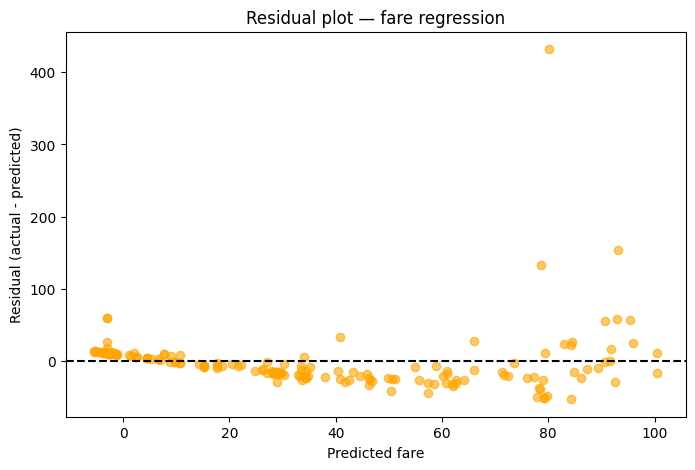

In [30]:
residuals = yr_test - yr_pred

plt.figure(figsize=(8, 5))
plt.scatter(yr_pred, residuals, alpha=0.6, color="orange")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot — fare regression")
plt.show()


# **COMBINED MODEL COMPARISON TABLE & RECOMMENDATION**

In [31]:
all_class_results = {**results, "RF + class_weight=balanced": balanced_res,
                      "RF + SMOTE": smote_res, "Random Forest (tuned)": tuned_res}

classification_table = pd.DataFrame([
    {"Model": name, "Accuracy": r["accuracy"], "Precision": r["precision"],
     "Recall": r["recall"], "F1": r["f1"], "AUC": r["auc"]}
    for name, r in all_class_results.items()
]).set_index("Model").round(4)

regression_table = pd.DataFrame([
    {"Model": "Linear Regression (fare)", "MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted_R2": adj_r2}
]).set_index("Model").round(4)

print("Classification models:")
display(classification_table)
print("\nRegression model (separate metric group -- not on the same scale as classification):")
display(regression_table)


Classification models:


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
Decision Tree,0.8090,0.8148,0.6471,0.7213,0.8560
Random Forest,0.8146,0.7778,0.7206,0.7481,0.8215
RF + class_weight=balanced,0.8034,0.7538,0.7206,0.7368,0.8164
RF + SMOTE,0.8315,0.7794,0.7794,0.7794,0.8289
Random Forest (tuned),0.8146,0.8182,0.6618,0.7317,0.8404



Regression model (separate metric group -- not on the same scale as classification):


,MAE,RMSE,R2,Adjusted_R2
Model,,,,
Linear Regression (fare),21.0986,41.7021,0.3482,0.3213


# **PERSIST THE BEST COMPLETE PIPELINE**

In [ ]:
full_pipeline = best_rf_pipe 

joblib.dump(full_pipeline, "titanic_survival_pipeline.joblib")
print("Saved -> titanic_survival_pipeline.joblib")


Saved -> titanic_survival_pipeline.joblib


In [35]:
# Reload and confirm it predicts correctly on RAW, unprocessed input
reloaded_pipeline = joblib.load("titanic_survival_pipeline.joblib")

raw_sample = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29.0, "sibsp": 0, "parch": 0, "fare": 100.0, "embarked": "S"},
    {"pclass": 3, "sex": "male", "age": 25.0, "sibsp": 0, "parch": 0, "fare": 7.5, "embarked": "S"},
])

raw_predictions = reloaded_pipeline.predict(raw_sample)
raw_probabilities = reloaded_pipeline.predict_proba(raw_sample)[:, 1]

print("Predictions on raw sample input:", raw_predictions)
print("Survival probabilities:", np.round(raw_probabilities, 3))
assert reloaded_pipeline.predict(raw_sample).shape[0] == 2
print("\nReloaded pipeline confirmed working end-to-end on raw, unprocessed input.")


Predictions on raw sample input: [1 0]
Survival probabilities: [0.929 0.105]

Reloaded pipeline confirmed working end-to-end on raw, unprocessed input.
